# 顧客離脱予測モデル
データ前処理とモデル構築

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')

## 1. データの読み込み

In [20]:
DATA_DIR = '../data/'
train = pd.read_csv(DATA_DIR + 'train.csv')
test = pd.read_csv(DATA_DIR + 'test.csv')

print(f'訓練データ: {train.shape}')
print(f'テストデータ: {test.shape}')
print(f'\n訓練データのカラム:\n{train.columns.tolist()}')
print(f'\nテストデータのカラム:\n{test.columns.tolist()}')

訓練データ: (594194, 21)
テストデータ: (254655, 20)

訓練データのカラム:
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

テストデータのカラム:
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 2. データの前処理

In [21]:
# カテゴリ変数のエンコーディング
# ターゲット変数の処理
if 'Churn' in train.columns:
    if train['Churn'].dtype == 'object':
        le_target = LabelEncoder()
        y_train = le_target.fit_transform(train['Churn'])
        train_data = train.drop('Churn', axis=1)
    else:
        y_train = train['Churn']
        train_data = train.drop('Churn', axis=1)
else:
    train_data = train.copy()
    y_train = None

# IDカラムの削除
if 'id' in train_data.columns:
    train_data = train_data.drop('id', axis=1)
if 'id' in test.columns:
    test_data = test.drop('id', axis=1)
else:
    test_data = test.copy()

# カテゴリ変数のワンホットエンコーディング
categorical_features = train_data.select_dtypes(include=['object']).columns.tolist()
train_data_encoded = pd.get_dummies(train_data, columns=categorical_features, drop_first=True)
test_data_encoded = pd.get_dummies(test_data, columns=categorical_features, drop_first=True)

# テストデータに訓練データにない列を追加
for col in train_data_encoded.columns:
    if col not in test_data_encoded.columns:
        test_data_encoded[col] = 0

# テストデータの余分な列を削除
test_data_encoded = test_data_encoded[train_data_encoded.columns]

print(f'訓練データ（前処理後）: {train_data_encoded.shape}')
print(f'テストデータ（前処理後）: {test_data_encoded.shape}')

訓練データ（前処理後）: (594194, 30)
テストデータ（前処理後）: (254655, 30)


In [22]:
# 特徴量のスケーリング
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train_data_encoded)
X_test_scaled = scaler.transform(test_data_encoded)

print('特徴量スケーリング完了')

特徴量スケーリング完了


## 3. 訓練・検証データの分割

In [23]:
# 訓練・検証データの分割
X_train, X_val, y_train_split, y_val = train_test_split(
    X_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f'訓練データサイズ: {X_train.shape}')
print(f'検証データサイズ: {X_val.shape}')
print(f'\nクラス分布（訓練）: {np.bincount(y_train_split)}')
print(f'クラス分布（検証）: {np.bincount(y_val)}')

訓練データサイズ: (475355, 30)
検証データサイズ: (118839, 30)

クラス分布（訓練）: [368301 107054]
クラス分布（検証）: [92076 26763]


## 4. モデル構築と評価

In [24]:
# モデルの訓練
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for model_name, model in models.items():
    print(f'\n{model_name}を訓練中...')
    model.fit(X_train, y_train_split)
    
    # 検証データで予測
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # メトリクスの計算
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }
    
    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'ROC-AUC:   {roc_auc:.4f}')


Logistic Regressionを訓練中...
Accuracy:  0.8545
Precision: 0.6839
Recall:    0.6578
F1-Score:  0.6706
ROC-AUC:   0.9084

Random Forestを訓練中...
Accuracy:  0.8431
Precision: 0.6721
Recall:    0.5926
F1-Score:  0.6299
ROC-AUC:   0.8954

Gradient Boostingを訓練中...
Accuracy:  0.8579
Precision: 0.7001
Recall:    0.6459
F1-Score:  0.6719
ROC-AUC:   0.9134


In [25]:
# 結果の比較
results_df = pd.DataFrame(
    {mk: {k: v[k] for k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}
     for mk, v in results.items()}
).T

print('\n=== モデル比較 ===')
print(results_df.round(4))


=== モデル比較 ===
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.8545     0.6839  0.6578  0.6706   0.9084
Random Forest          0.8431     0.6721  0.5926  0.6299   0.8954
Gradient Boosting      0.8579     0.7001  0.6459  0.6719   0.9134


## 5. 最適モデルの選択と詳細分析

In [26]:
# 最適モデルの選択（F1スコアが最高のモデル）
best_model_name = results_df['f1'].idxmax()
best_model = results[best_model_name]['model']

print(f'最適モデル: {best_model_name}')
print(f'F1-Score: {results[best_model_name]["f1"]:.4f}')

最適モデル: Gradient Boosting
F1-Score: 0.6719


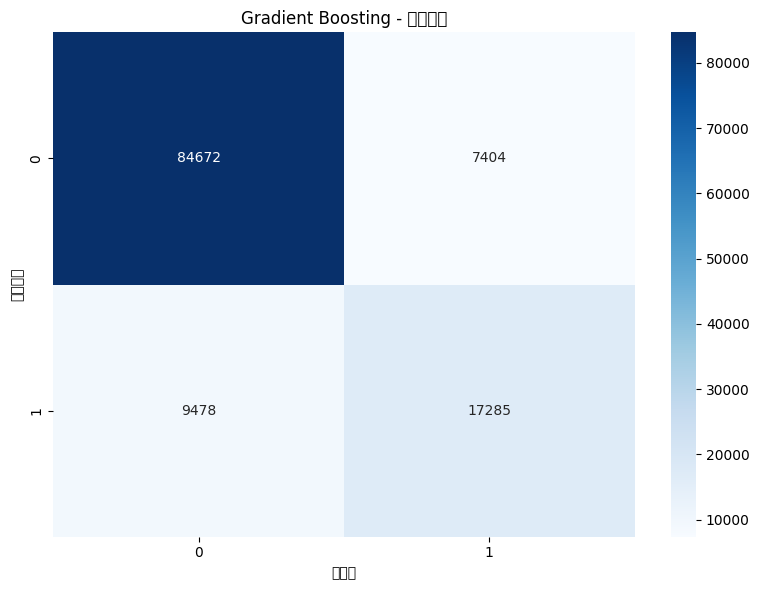


分類レポート:
              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91     92076
       Churn       0.70      0.65      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.85      0.86      0.86    118839



In [27]:
# 混同行列
y_pred_best = best_model.predict(X_val)
cm = confusion_matrix(y_val, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('予測値')
ax.set_ylabel('実際の値')
ax.set_title(f'{best_model_name} - 混同行列')
plt.tight_layout()
plt.show()

print('\n分類レポート:')
print(classification_report(y_val, y_pred_best, target_names=['No Churn', 'Churn']))

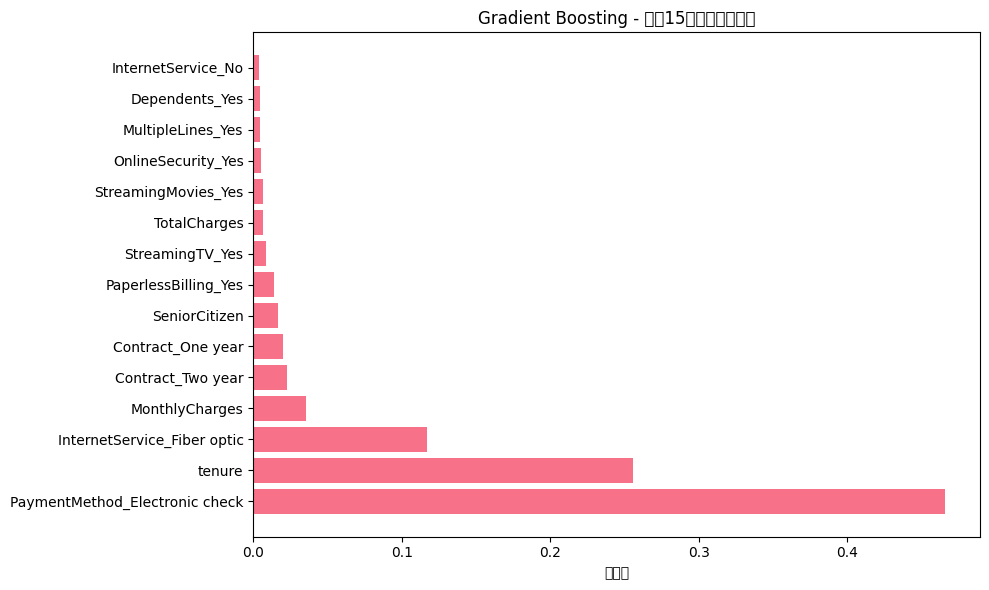


特徴量の重要度 TOP10:
                           feature  importance
28  PaymentMethod_Electronic check    0.466136
1                           tenure    0.255884
10     InternetService_Fiber optic    0.117010
2                   MonthlyCharges    0.035335
25               Contract_Two year    0.022665
24               Contract_One year    0.019968
0                    SeniorCitizen    0.016718
26            PaperlessBilling_Yes    0.013871
21                 StreamingTV_Yes    0.008801
3                     TotalCharges    0.006916


In [28]:
# 特徴量の重要度（ツリーベースモデルの場合）
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame(
        {'feature': train_data_encoded.columns, 'importance': importances}
    ).sort_values('importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(15), feature_importance_df['importance'].head(15).values)
    ax.set_yticks(range(15))
    ax.set_yticklabels(feature_importance_df['feature'].head(15).values)
    ax.set_xlabel('重要度')
    ax.set_title(f'{best_model_name} - 上位15の重要な特徴量')
    plt.tight_layout()
    plt.show()
    
    print('\n特徴量の重要度 TOP10:')
    print(feature_importance_df.head(10))

## 6. テストセットへの予測

In [29]:
# テストセットへの予測
y_test_pred = best_model.predict(X_test_scaled)

# 提出ファイルの作成
submission = pd.DataFrame({
    'id': test['id'] if 'id' in test.columns else range(len(y_test_pred)),
    'Churn': y_test_pred
})

print(submission.head(10))
print(f'\n予測の内訳:')
print(submission['Churn'].value_counts())

       id  Churn
0  594194      0
1  594195      0
2  594196      0
3  594197      0
4  594198      1
5  594199      0
6  594200      1
7  594201      0
8  594202      0
9  594203      0

予測の内訳:
Churn
0    203954
1     50701
Name: count, dtype: int64


In [30]:
# 提出ファイルの保存
submission.to_csv('../data/submission.csv', index=False)
print('提出ファイルを ../data/submission.csv に保存しました')

提出ファイルを ../data/submission.csv に保存しました
